<div style="width:100vw; margin-left:-50vw; left:50%; position:relative;">
  <img src="https://i.postimg.cc/MTBpfsYw/CURSO-PYTHON-SIMPEG.png" style="width:100%;">
</div>


# FWI: Evaluación de parámetros en aprendizaje profundo supervisado

Este notebook presenta ejercicios orientados al análisis de la respuesta del modelo de inversión de onda completa (FWI) 2D ante variaciones en los parámetros de entrenamiento. En particular, se evalúa el efecto del número de épocas y del uso de las normas L1 y L2 como funciones de pérdida sobre los resultados obtenidos.


<div style="width:100vw; margin-left:-50vw; left:50%; position:relative;">
  <img src="https://i.postimg.cc/zf5MJhH6/Chat-GPT-Image-24-jul-2026-02-24-27-a-m.png" style="width:100%;">
</div>

## 1. Preparación del entorno

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/OpenFWI

/content/drive/.shortcut-targets-by-id/1hv288BzP1RHNX1IITagQzJTSBay_unfJ/OpenFWI


In [ ]:

#@markdown Esta celda crea una carpeta en el Drive personal de cada estudiante para guardar los modelos, registros y visualizaciones generados durante el entrenamiento, sin modificar la carpeta compartida del curso.
#@markdown

import os

# Carpeta personal de cada estudiante
OUTPUT_ROOT = "/content/drive/MyDrive/OpenFWI_resultados"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("✅ Carpeta principal de resultados:", OUTPUT_ROOT)

✅ Carpeta principal de resultados: /content/drive/MyDrive/OpenFWI_resultados


El conjunto de datos **FlatVel-A** para este tutorial está disponible en:

[![GoogleDrive](https://img.shields.io/static/v1.svg?logo=google-drive&logoColor=yellow&label=GDrive&message=Download&color=yellow)](https://drive.google.com/drive/folders/1u4pFvu7UnQozu-tLyyPdsQjRmAZ-kGil?usp=sharing)

<br>
<p align='left'>Datos: Datos sísmicos $p(g,t)$ $\ \ \ \ $ Etiqueta: Mapa de velocidades $c(x,z)$</p>

<br>

Hay tres pares de **datos y etiquetas**:

*fva_velocity1.npy* y *fva_data1.npy*

*fva_velocity2.npy* y *fva_data2.npy*

*fva_velocity3.npy* y *fva_data3.npy*

---
## 2. Carga e inspección de datos y etiquetas

In [ ]:
# @title 2.1 Carga de datos sísmicos y modelos de velocidad.
import numpy as np
velocity = np.load('Ejercicio_1/fva_velocity2.npy')
data = np.load('Ejercicio_1/fva_data2.npy')

In [ ]:
# @title 2.2 Verifica el tamaño del mapa de velocidad y de los datos sísmicos.

print('Velocity map size:', velocity.shape)
print('Seismic data size:', data.shape)


Velocity map size: (120, 1, 70, 70)
Seismic data size: (120, 5, 1000, 70)


# **EJERCICIO 1**  — Influencia del número de épocas


En este ejercicio se analizará cómo afecta el número de épocas al entrenamiento del modelo.

Entrena la red utilizando diferentes cantidades de épocas y compara los resultados obtenidos.

Realiza los siguientes experimentos:

- Entrenamiento con **15 épocas**
- Entrenamiento con **30 épocas**
- Entrenamiento con **50 épocas**

Después de entrenar el modelo en cada caso:

1. Observa las curvas de **loss de entrenamiento y validación** en TensorBoard.
2. Evalúa los resultados usando las métricas **MAE, MSE y SSIM**.
3. Analiza las imágenes predichas generadas por el modelo.

Finalmente responde:

- ¿Cómo cambia la calidad de las predicciones al aumentar el número de épocas?
- ¿Cuál número de épocas parece ser el más adecuado?

In [ ]:
#@title 1.1 Entrenamiento con **15 épocas**

Dataset = "flatvel-tutorial" #@param {type:"string"}
Carpeta = "epocas_15" #@param {type:"string"}
Nombre_de_la_red = "InversionNet" #@param {type:"string"}
Norma_L1 = 1.0 #@param {type:"number"}
Norma_L2 = 0.0 #@param {type:"number"}
Tensorboard = True #@param {type:"boolean"}
Conjunto_de_entrenamiento = "Ejercicio_1_train.txt" #@param {type:"string"}
Conjunto_de_validacion = "Ejercicio_1_val.txt" #@param {type:"string"}
Learning_rate = 0.0001 #@param {type:"number"}
Batch_size = 120 #@param {type:"integer"}
Epocas_por_bloque = 3 #@param {type:"integer"}
Bloques = 5 #@param {type:"integer"}
Workers = 2 #@param {type:"integer"}

flag_tensorboard = "--tensorboard" if Tensorboard else ""

!python train.py -ds {Dataset} -n {Carpeta} -m {Nombre_de_la_red} -g1v {Norma_L1} -g2v {Norma_L2} {flag_tensorboard} -t {Conjunto_de_entrenamiento} -v {Conjunto_de_validacion} --lr {Learning_rate} -b {Batch_size} -eb {Epocas_por_bloque} -nb {Bloques} -j {Workers} --output-path {OUTPUT_ROOT} --log-path {OUTPUT_ROOT}

2026-08-07 07:53:46.850637: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Namespace(device='cuda', dataset='flatvel-tutorial', file_size=None, anno_path='split_files', train_anno='split_files/Ejercicio_1_train.txt', val_anno='split_files/Ejercicio_1_val.txt', output_path='/content/drive/MyDrive/OpenFWI_resultados/epocas_15/', log_path='/content/drive/MyDrive/OpenFWI_resultados/epocas_15/', save_name='epocas_15', suffix=None, model='InversionNet', up_mode=None, sample_spatial=1.0, sample_temporal=1, batch_size=120, lr=0.0001, lr_milestones=[], momentum=0.9, weight_decay=0.0001, lr_gamma=0.1, lr_warmup_epochs=0, epoch_block=3, num_block=5, workers=2, k=1, print_freq=50, resume=None, start_epoch=0, lambda_g1v=1.0, lambda_g2v=0.0, sync_bn=False, wo

Archivo usado: /content/drive/MyDrive/OpenFWI_resultados/epocas_15/logs/train/events.out.tfevents.1786089240.99d46dff3be5.2111.0
Archivo usado: /content/drive/MyDrive/OpenFWI_resultados/epocas_15/logs/val/events.out.tfevents.1786089240.99d46dff3be5.2111.1


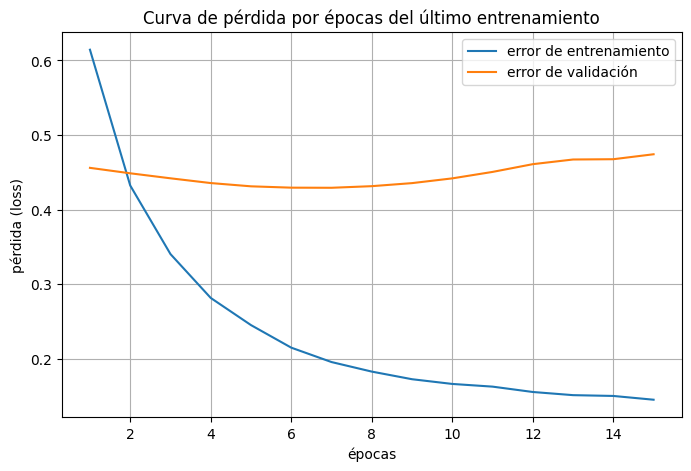

In [ ]:
# @title 1.2 Curva de pérdida por épocas

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

def obtener_ultimo_evento(ruta):
    archivos = glob.glob(os.path.join(ruta, "events.out.tfevents.*"))

    if len(archivos) == 0:
        raise FileNotFoundError(f"No se encontraron archivos de eventos en: {ruta}")

    ultimo_archivo = max(archivos, key=os.path.getmtime)
    print("Archivo usado:", ultimo_archivo)
    return ultimo_archivo

def obtener_loss_ultimo(ruta):
    archivo_evento = obtener_ultimo_evento(ruta)
    ea = event_accumulator.EventAccumulator(archivo_evento)
    ea.Reload()

    loss = ea.Scalars("loss")
    pasos = [x.step for x in loss]
    valores = [x.value for x in loss]

    return pasos, valores

# Leer pérdidas del experimento actual desde el Drive personal
RUTA_MODELO = os.path.join(OUTPUT_ROOT, Carpeta)

pasos_train, valores_train = obtener_loss_ultimo(
    os.path.join(RUTA_MODELO, "logs", "train")
)
pasos_val, valores_val = obtener_loss_ultimo(
    os.path.join(RUTA_MODELO, "logs", "val")
)

# La validación se guarda una vez por época
num_epocas = len(valores_val)

# El entrenamiento se guarda por iteración, entonces se agrupa por época
iters_por_epoca = len(valores_train) / num_epocas

loss_train_epoca = []

for e in range(num_epocas):
    inicio = int(round(e * iters_por_epoca))
    fin = int(round((e + 1) * iters_por_epoca))
    loss_train_epoca.append(np.mean(valores_train[inicio:fin]))

# Eje x en épocas
epocas = np.arange(1, num_epocas + 1)

# Graficar
plt.figure(figsize=(8,5))
plt.plot(epocas, loss_train_epoca, label="error de entrenamiento")
plt.plot(epocas, valores_val, label="error de validación")
plt.xlabel("épocas")
plt.ylabel("pérdida (loss)")
plt.title("Curva de pérdida por épocas del último entrenamiento")
plt.legend()
plt.grid(True)
plt.show()


Carpeta actual:
/content/drive/.shortcut-targets-by-id/1hv288BzP1RHNX1IITagQzJTSBay_unfJ/OpenFWI
Namespace(device='cuda', dataset='flatvel-tutorial', file_size=None, anno_path='split_files', val_anno='split_files/Ejercicio_1_train.txt', output_path='/content/drive/MyDrive/OpenFWI_resultados/epocas_15/', save_name='epocas_15', suffix=None, model='InversionNet', norm='bn', up_mode=None, sample_spatial=1.0, sample_temporal=1, batch_size=50, workers=16, k=1, resume='/content/drive/MyDrive/OpenFWI_resultados/epocas_15/checkpoint.pth', vis=True, vis_suffix=None, vis_batch=2, vis_sample=3, missing=0, std=0)
torch version:  2.11.0+cu128
torchvision version:  0.26.0+cu128
Loading data
Loading validation data
Creating data loaders
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. 

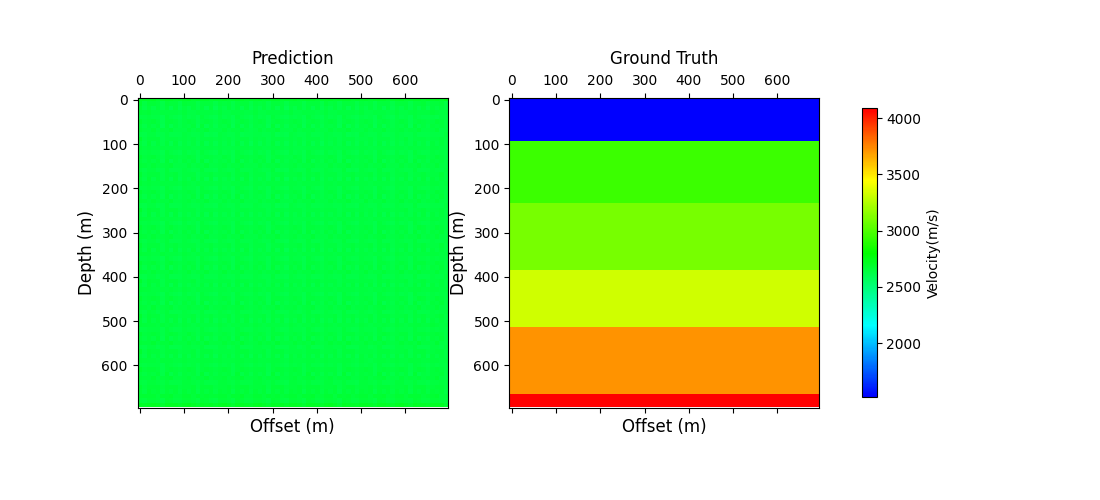

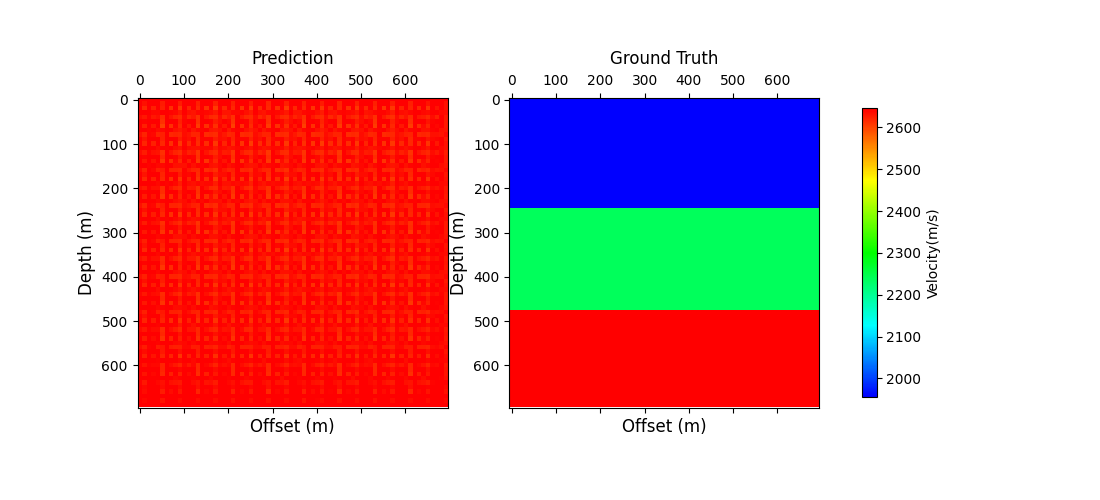

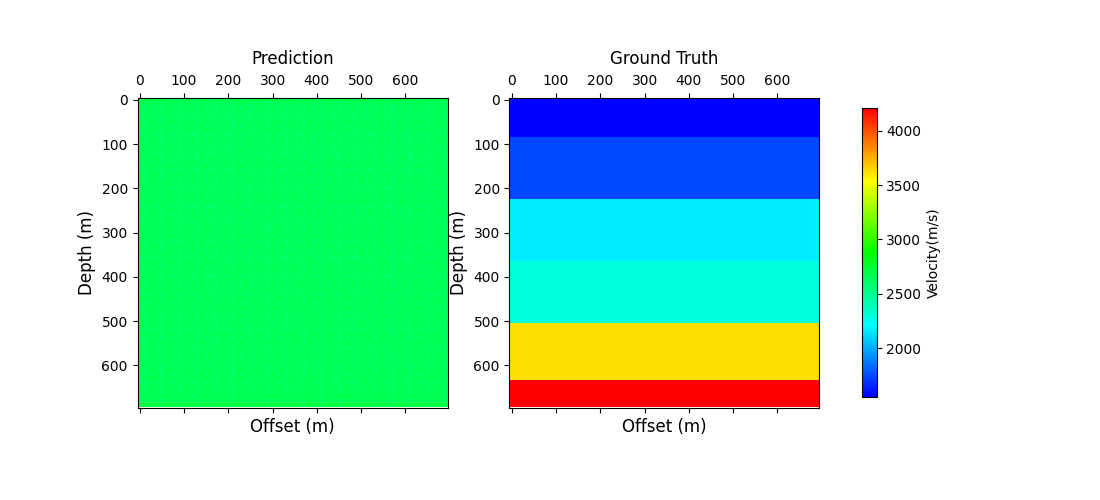

In [ ]:
#@title #1.3. Validación sobre el conjunto de entrenamiento
#@markdown Para verificar cómo se comporta la red entrenada en los datos de entrenamiento, establecemos "-v tutorial_train.txt"

#@markdown Para probar el rendimiento de la red en el conjunto de entrenamiento *fva_velocity1.npy*, *fva_data1.npy*, *fva_velocity2.npy* y *fva_data2.npy*

# Volver a la carpeta correcta de OpenFWI

import os

ruta_openfwi = "/content/drive/.shortcut-targets-by-id/1hv288BzP1RHNX1IITagQzJTSBay_unfJ/OpenFWI"

os.chdir(ruta_openfwi)

print("Carpeta actual:")
print(os.getcwd())

dataset = "flatvel-tutorial" #@param {type:"string"}
carpeta = "epocas_15" #@param {type:"string"}
nombre_red = "InversionNet" #@param {type:"string"}
archivo_test = "Ejercicio_1_train.txt" #@param {type:"string"}
checkpoint = "checkpoint.pth" #@param {type:"string"}

visualizar = True #@param {type:"boolean"}
batches_visualizar = 2 #@param {type:"integer"}
samples_por_batch = 3 #@param {type:"integer"}

flag_vis = "--vis" if visualizar else ""

!python test.py -ds {dataset} -n {carpeta} -m {nombre_red} -v {archivo_test} -r {checkpoint} {flag_vis} -vb {batches_visualizar} -vsa {samples_por_batch} --output-path {OUTPUT_ROOT}

from IPython.display import Image, display

base = os.path.join(OUTPUT_ROOT, carpeta, "visualization")

a = Image(f"{base}/V_0_0.png", width=600)
b = Image(f"{base}/V_0_1.png", width=600)
c = Image(f"{base}/V_0_2.png", width=600)

display(a, b, c)

In [ ]:
#@title 2.1 Entrenamiento con **25 épocas**

Dataset = "flatvel-tutorial" #@param {type:"string"}
Carpeta = "epocas_25" #@param {type:"string"}
Nombre_de_la_red = "InversionNet" #@param {type:"string"}
Norma_L1 = 1.0 #@param {type:"number"}
Norma_L2 = 0.0 #@param {type:"number"}
Tensorboard = True #@param {type:"boolean"}
Conjunto_de_entrenamiento = "Ejercicio_1_train.txt" #@param {type:"string"}
Conjunto_de_validacion = "Ejercicio_1_val.txt" #@param {type:"string"}
Learning_rate = 0.0001 #@param {type:"number"}
Batch_size = 120 #@param {type:"integer"}
Epocas_por_bloque = 5 #@param {type:"integer"}
Bloques = 5 #@param {type:"integer"}
Workers = 2 #@param {type:"integer"}

flag_tensorboard = "--tensorboard" if Tensorboard else ""

!python train.py -ds {Dataset} -n {Carpeta} -m {Nombre_de_la_red} -g1v {Norma_L1} -g2v {Norma_L2} {flag_tensorboard} -t {Conjunto_de_entrenamiento} -v {Conjunto_de_validacion} --lr {Learning_rate} -b {Batch_size} -eb {Epocas_por_bloque} -nb {Bloques} -j {Workers} --output-path {OUTPUT_ROOT} --log-path {OUTPUT_ROOT}

Namespace(device='cuda', dataset='flatvel-tutorial', file_size=None, anno_path='split_files', train_anno='split_files/Ejercicio_1_train.txt', val_anno='split_files/Ejercicio_1_val.txt', output_path='/content/drive/MyDrive/OpenFWI_resultados/epocas_25/', log_path='/content/drive/MyDrive/OpenFWI_resultados/epocas_25/', save_name='epocas_25', suffix=None, model='InversionNet', up_mode=None, sample_spatial=1.0, sample_temporal=1, batch_size=120, lr=0.0001, lr_milestones=[], momentum=0.9, weight_decay=0.0001, lr_gamma=0.1, lr_warmup_epochs=0, epoch_block=5, num_block=5, workers=2, k=1, print_freq=50, resume=None, start_epoch=0, lambda_g1v=1.0, lambda_g2v=0.0, sync_bn=False, world_size=1, dist_url='env://', tensorboard=True, epochs=25)
torch version:  2.11.0+cu128
torchvision version:  0.26.0+cu128
Not using distributed mode
Loading data
Loading training data
Loading validation data
Creating data loaders
Creating model
Start training
Epoch: [0]  [0/2]  eta: 0:01:29  lr: 0.0001  samples/s: 2.

Archivo usado: /content/drive/MyDrive/OpenFWI_resultados/epocas_25/logs/train/events.out.tfevents.1786089851.99d46dff3be5.5702.0
Archivo usado: /content/drive/MyDrive/OpenFWI_resultados/epocas_25/logs/val/events.out.tfevents.1786089851.99d46dff3be5.5702.1


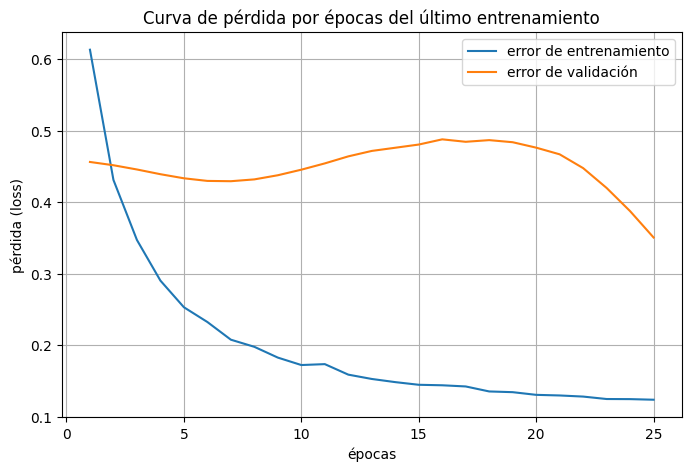

In [ ]:
# @title 2.2 Curva de pérdida por épocas

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

def obtener_ultimo_evento(ruta):
    archivos = glob.glob(os.path.join(ruta, "events.out.tfevents.*"))

    if len(archivos) == 0:
        raise FileNotFoundError(f"No se encontraron archivos de eventos en: {ruta}")

    ultimo_archivo = max(archivos, key=os.path.getmtime)
    print("Archivo usado:", ultimo_archivo)
    return ultimo_archivo

def obtener_loss_ultimo(ruta):
    archivo_evento = obtener_ultimo_evento(ruta)
    ea = event_accumulator.EventAccumulator(archivo_evento)
    ea.Reload()

    loss = ea.Scalars("loss")
    pasos = [x.step for x in loss]
    valores = [x.value for x in loss]

    return pasos, valores

# Leer pérdidas del experimento actual desde el Drive personal
RUTA_MODELO = os.path.join(OUTPUT_ROOT, Carpeta)

pasos_train, valores_train = obtener_loss_ultimo(
    os.path.join(RUTA_MODELO, "logs", "train")
)
pasos_val, valores_val = obtener_loss_ultimo(
    os.path.join(RUTA_MODELO, "logs", "val")
)

# La validación se guarda una vez por época
num_epocas = len(valores_val)

# El entrenamiento se guarda por iteración, entonces se agrupa por época
iters_por_epoca = len(valores_train) / num_epocas

loss_train_epoca = []

for e in range(num_epocas):
    inicio = int(round(e * iters_por_epoca))
    fin = int(round((e + 1) * iters_por_epoca))
    loss_train_epoca.append(np.mean(valores_train[inicio:fin]))

# Eje x en épocas
epocas = np.arange(1, num_epocas + 1)

# Graficar
plt.figure(figsize=(8,5))
plt.plot(epocas, loss_train_epoca, label="error de entrenamiento")
plt.plot(epocas, valores_val, label="error de validación")
plt.xlabel("épocas")
plt.ylabel("pérdida (loss)")
plt.title("Curva de pérdida por épocas del último entrenamiento")
plt.legend()
plt.grid(True)
plt.show()


Carpeta actual:
/content/drive/.shortcut-targets-by-id/1hv288BzP1RHNX1IITagQzJTSBay_unfJ/OpenFWI
Namespace(device='cuda', dataset='flatvel-tutorial', file_size=None, anno_path='split_files', val_anno='split_files/Ejercicio_1_train.txt', output_path='/content/drive/MyDrive/OpenFWI_resultados/epocas_25/', save_name='epocas_25', suffix=None, model='InversionNet', norm='bn', up_mode=None, sample_spatial=1.0, sample_temporal=1, batch_size=50, workers=16, k=1, resume='/content/drive/MyDrive/OpenFWI_resultados/epocas_25/checkpoint.pth', vis=True, vis_suffix=None, vis_batch=2, vis_sample=3, missing=0, std=0)
torch version:  2.11.0+cu128
torchvision version:  0.26.0+cu128
Loading data
Loading validation data
Creating data loaders
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. 

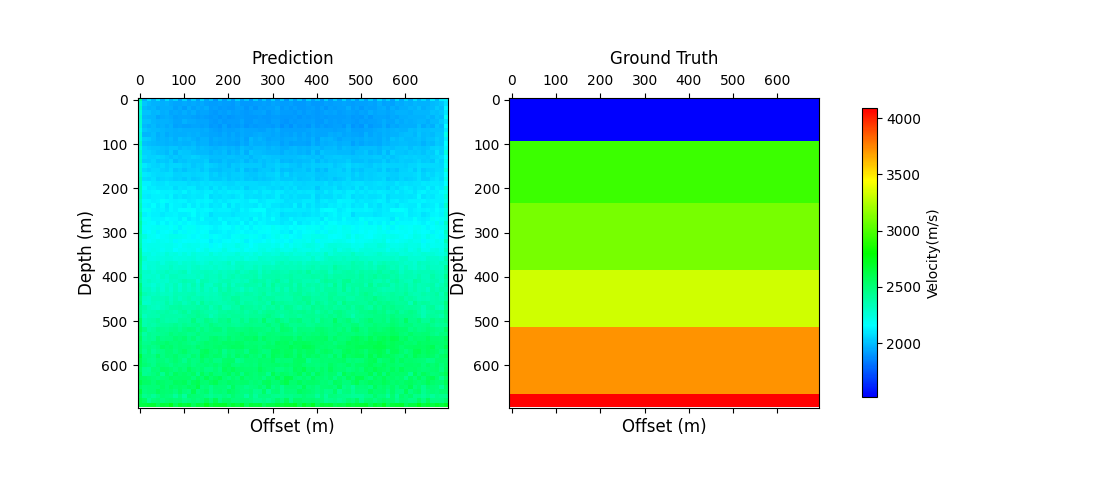

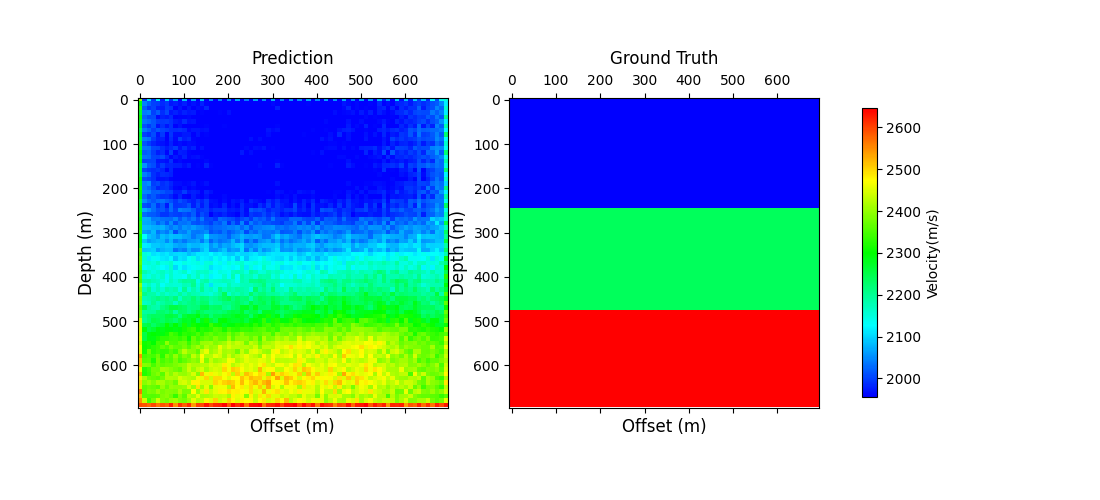

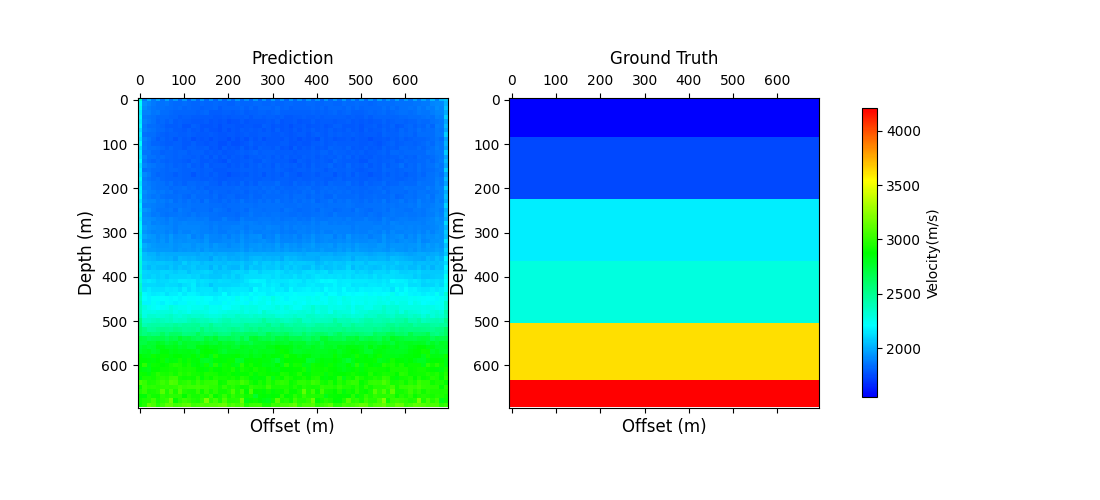

In [ ]:
#@title #2.3. Validación sobre el conjunto de entrenamiento
#@markdown Para verificar cómo se comporta la red entrenada en los datos de entrenamiento, establecemos "-v tutorial_train.txt"

#@markdown Para probar el rendimiento de la red en el conjunto de entrenamiento *fva_velocity1.npy*, *fva_data1.npy*, *fva_velocity2.npy* y *fva_data2.npy*

# Volver a la carpeta correcta de OpenFWI

import os

ruta_openfwi = "/content/drive/.shortcut-targets-by-id/1hv288BzP1RHNX1IITagQzJTSBay_unfJ/OpenFWI"

os.chdir(ruta_openfwi)

print("Carpeta actual:")
print(os.getcwd())

dataset = "flatvel-tutorial" #@param {type:"string"}
carpeta = "epocas_25" #@param {type:"string"}
nombre_red = "InversionNet" #@param {type:"string"}
archivo_test = "Ejercicio_1_train.txt" #@param {type:"string"}
checkpoint = "checkpoint.pth" #@param {type:"string"}

visualizar = True #@param {type:"boolean"}
batches_visualizar = 2 #@param {type:"integer"}
samples_por_batch = 3 #@param {type:"integer"}

flag_vis = "--vis" if visualizar else ""

!python test.py -ds {dataset} -n {carpeta} -m {nombre_red} -v {archivo_test} -r {checkpoint} {flag_vis} -vb {batches_visualizar} -vsa {samples_por_batch} --output-path {OUTPUT_ROOT}

from IPython.display import Image, display

base = os.path.join(OUTPUT_ROOT, carpeta, "visualization")

a = Image(f"{base}/V_0_0.png", width=600)
b = Image(f"{base}/V_0_1.png", width=600)
c = Image(f"{base}/V_0_2.png", width=600)

display(a, b, c)

In [ ]:
#@title 3.1 Entrenamiento con **50 épocas**

Dataset = "flatvel-tutorial" #@param {type:"string"}
Carpeta = "epocas_50" #@param {type:"string"}
Nombre_de_la_red = "InversionNet" #@param {type:"string"}
Norma_L1 = 1.0 #@param {type:"number"}
Norma_L2 = 0.0 #@param {type:"number"}
Tensorboard = True #@param {type:"boolean"}
Conjunto_de_entrenamiento = "Ejercicio_1_train.txt" #@param {type:"string"}
Conjunto_de_validacion = "Ejercicio_1_val.txt" #@param {type:"string"}
Learning_rate = 0.0001 #@param {type:"number"}
Batch_size = 120 #@param {type:"integer"}
Epocas_por_bloque = 10 #@param {type:"integer"}
Bloques = 5 #@param {type:"integer"}
Workers = 2 #@param {type:"integer"}

flag_tensorboard = "--tensorboard" if Tensorboard else ""

!python train.py -ds {Dataset} -n {Carpeta} -m {Nombre_de_la_red} -g1v {Norma_L1} -g2v {Norma_L2} {flag_tensorboard} -t {Conjunto_de_entrenamiento} -v {Conjunto_de_validacion} --lr {Learning_rate} -b {Batch_size} -eb {Epocas_por_bloque} -nb {Bloques} -j {Workers} --output-path {OUTPUT_ROOT} --log-path {OUTPUT_ROOT}

Namespace(device='cuda', dataset='flatvel-tutorial', file_size=None, anno_path='split_files', train_anno='split_files/Ejercicio_1_train.txt', val_anno='split_files/Ejercicio_1_val.txt', output_path='/content/drive/MyDrive/OpenFWI_resultados/epocas_50/', log_path='/content/drive/MyDrive/OpenFWI_resultados/epocas_50/', save_name='epocas_50', suffix=None, model='InversionNet', up_mode=None, sample_spatial=1.0, sample_temporal=1, batch_size=120, lr=0.0001, lr_milestones=[], momentum=0.9, weight_decay=0.0001, lr_gamma=0.1, lr_warmup_epochs=0, epoch_block=10, num_block=5, workers=2, k=1, print_freq=50, resume=None, start_epoch=0, lambda_g1v=1.0, lambda_g2v=0.0, sync_bn=False, world_size=1, dist_url='env://', tensorboard=True, epochs=50)
torch version:  2.11.0+cu128
torchvision version:  0.26.0+cu128
Not using distributed mode
Loading data
Loading training data
Loading validation data
Creating data loaders
Creating model
Start training
Epoch: [0]  [0/2]  eta: 0:01:30  lr: 0.0001  samples/s: 2

Archivo usado: /content/drive/MyDrive/OpenFWI_resultados/epocas_50/logs/train/events.out.tfevents.1786090254.99d46dff3be5.8050.0
Archivo usado: /content/drive/MyDrive/OpenFWI_resultados/epocas_50/logs/val/events.out.tfevents.1786090254.99d46dff3be5.8050.1


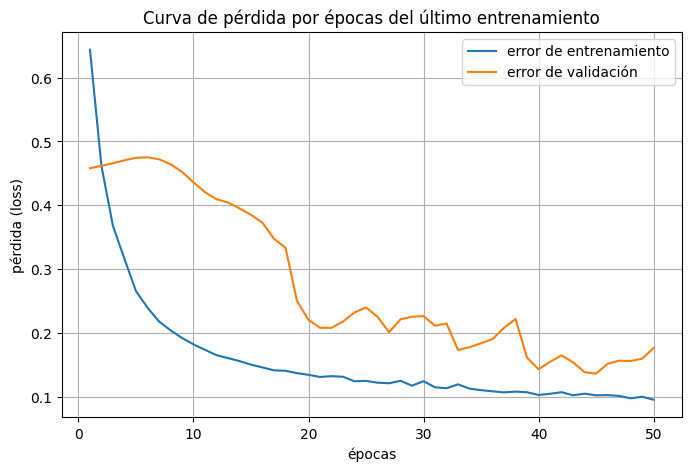

In [ ]:
# @title 3.2 Curva de pérdida por épocas

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

def obtener_ultimo_evento(ruta):
    archivos = glob.glob(os.path.join(ruta, "events.out.tfevents.*"))

    if len(archivos) == 0:
        raise FileNotFoundError(f"No se encontraron archivos de eventos en: {ruta}")

    ultimo_archivo = max(archivos, key=os.path.getmtime)
    print("Archivo usado:", ultimo_archivo)
    return ultimo_archivo

def obtener_loss_ultimo(ruta):
    archivo_evento = obtener_ultimo_evento(ruta)
    ea = event_accumulator.EventAccumulator(archivo_evento)
    ea.Reload()

    loss = ea.Scalars("loss")
    pasos = [x.step for x in loss]
    valores = [x.value for x in loss]

    return pasos, valores

# Leer pérdidas del experimento actual desde el Drive personal
RUTA_MODELO = os.path.join(OUTPUT_ROOT, Carpeta)

pasos_train, valores_train = obtener_loss_ultimo(
    os.path.join(RUTA_MODELO, "logs", "train")
)
pasos_val, valores_val = obtener_loss_ultimo(
    os.path.join(RUTA_MODELO, "logs", "val")
)

# La validación se guarda una vez por época
num_epocas = len(valores_val)

# El entrenamiento se guarda por iteración, entonces se agrupa por época
iters_por_epoca = len(valores_train) / num_epocas

loss_train_epoca = []

for e in range(num_epocas):
    inicio = int(round(e * iters_por_epoca))
    fin = int(round((e + 1) * iters_por_epoca))
    loss_train_epoca.append(np.mean(valores_train[inicio:fin]))

# Eje x en épocas
epocas = np.arange(1, num_epocas + 1)

# Graficar
plt.figure(figsize=(8,5))
plt.plot(epocas, loss_train_epoca, label="error de entrenamiento")
plt.plot(epocas, valores_val, label="error de validación")
plt.xlabel("épocas")
plt.ylabel("pérdida (loss)")
plt.title("Curva de pérdida por épocas del último entrenamiento")
plt.legend()
plt.grid(True)
plt.show()


Carpeta actual:
/content/drive/.shortcut-targets-by-id/1hv288BzP1RHNX1IITagQzJTSBay_unfJ/OpenFWI
Namespace(device='cuda', dataset='flatvel-tutorial', file_size=None, anno_path='split_files', val_anno='split_files/Ejercicio_1_train.txt', output_path='/content/drive/MyDrive/OpenFWI_resultados/epocas_50/', save_name='epocas_50', suffix=None, model='InversionNet', norm='bn', up_mode=None, sample_spatial=1.0, sample_temporal=1, batch_size=50, workers=16, k=1, resume='/content/drive/MyDrive/OpenFWI_resultados/epocas_50/checkpoint.pth', vis=True, vis_suffix=None, vis_batch=2, vis_sample=3, missing=0, std=0)
torch version:  2.11.0+cu128
torchvision version:  0.26.0+cu128
Loading data
Loading validation data
Creating data loaders
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. 

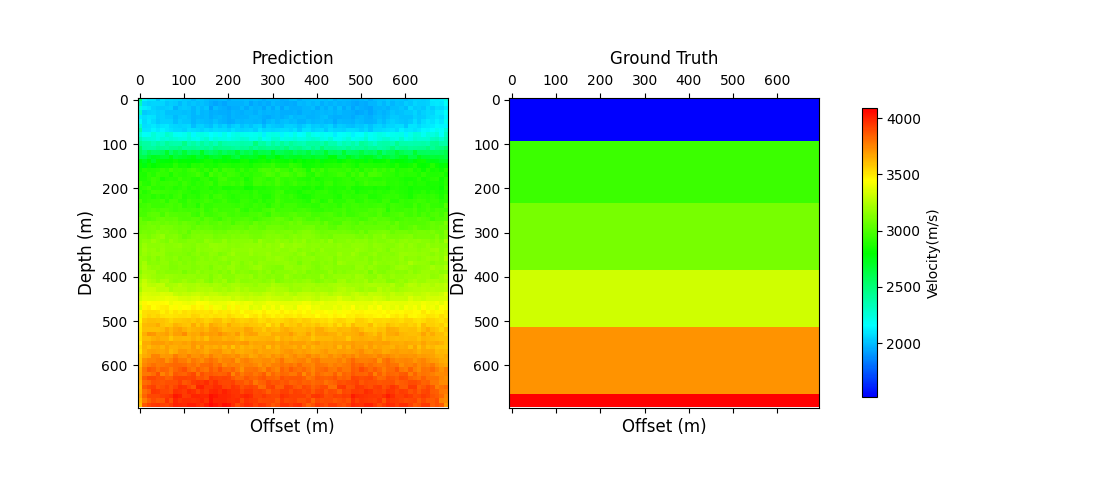

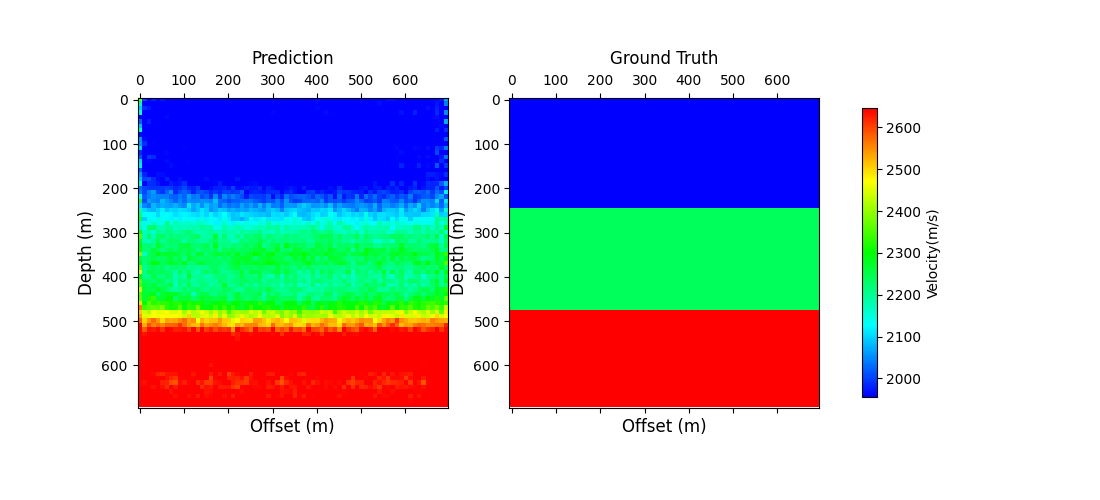

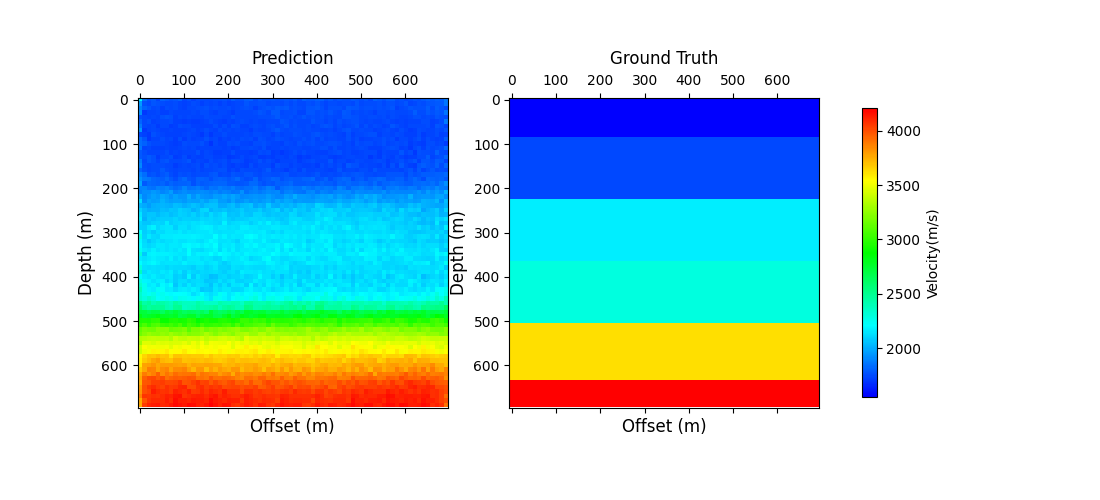

In [ ]:
#@title #3.3. Validación sobre el conjunto de entrenamiento
#@markdown Para verificar cómo se comporta la red entrenada en los datos de entrenamiento, establecemos "-v tutorial_train.txt"

#@markdown Para probar el rendimiento de la red en el conjunto de entrenamiento *fva_velocity1.npy*, *fva_data1.npy*, *fva_velocity2.npy* y *fva_data2.npy*

# Volver a la carpeta correcta de OpenFWI

import os

ruta_openfwi = "/content/drive/.shortcut-targets-by-id/1hv288BzP1RHNX1IITagQzJTSBay_unfJ/OpenFWI"

os.chdir(ruta_openfwi)

print("Carpeta actual:")
print(os.getcwd())

dataset = "flatvel-tutorial" #@param {type:"string"}
carpeta = "epocas_50" #@param {type:"string"}
nombre_red = "InversionNet" #@param {type:"string"}
archivo_test = "Ejercicio_1_train.txt" #@param {type:"string"}
checkpoint = "checkpoint.pth" #@param {type:"string"}

visualizar = True #@param {type:"boolean"}
batches_visualizar = 2 #@param {type:"integer"}
samples_por_batch = 3 #@param {type:"integer"}

flag_vis = "--vis" if visualizar else ""

!python test.py -ds {dataset} -n {carpeta} -m {nombre_red} -v {archivo_test} -r {checkpoint} {flag_vis} -vb {batches_visualizar} -vsa {samples_por_batch} --output-path {OUTPUT_ROOT}

from IPython.display import Image, display

base = os.path.join(OUTPUT_ROOT, carpeta, "visualization")

a = Image(f"{base}/V_0_0.png", width=600)
b = Image(f"{base}/V_0_1.png", width=600)
c = Image(f"{base}/V_0_2.png", width=600)

display(a, b, c)

# **EJERCICIO 2** — Influencia de las funciones de pérdida

Utiliza las siguientes funciones de pérdida para entrenar la red:

- Norma **L1 (MAE)**
- Norma **L2 (MSE)**
- **Combinación L1 + L2**



Entrena el modelo utilizando cada una de estas funciones de pérdida y **compara los resultados obtenidos**.

1. Ejecuta el entrenamiento usando únicamente **L1**.
2. Ejecuta el entrenamiento usando únicamente **L2**.
3. Ejecuta el entrenamiento usando la combinación **L1 + L2**.

Finalmente:

- Analiza cuál función de pérdida produce **mejores resultados** en la reconstrucción.
- Compara métricas como **MAE, MSE y SSIM**.
- Describe brevemente **qué diferencias observas en las predicciones del modelo**.



### Norma L1 (MAE)

La pérdida L1 calcula el promedio del error absoluto entre el modelo predicho y el modelo de referencia. Debido a que penaliza los errores de forma lineal, resulta menos sensible a valores atípicos y suele preservar mejor las discontinuidades y cambios bruscos presentes en el modelo de velocidad.

$$
\mathcal{L}_{L1}
=
\frac{1}{N}
\sum_{j=1}^{N}
\left|
g_{\theta}(d_i)_j-c_{i,j}
\right|
$$

donde $N$ corresponde al número total de píxeles o celdas del modelo de velocidad.

### Norma L2 (MSE)

La pérdida L2 calcula el promedio del error cuadrático entre la predicción y el modelo de referencia. Al elevar los errores al cuadrado, esta función penaliza con mayor intensidad las diferencias grandes, favoreciendo reconstrucciones más suaves y reduciendo errores de alta magnitud.

$$
\mathcal{L}_{L2}
=
\frac{1}{N}
\sum_{j=1}^{N}
\left(
g_{\theta}(d_i)_j-c_{i,j}
\right)^2
$$

### Combinación L1 + L2

La pérdida combinada busca aprovechar las ventajas de ambas métricas. La componente L1 favorece la conservación de bordes y discontinuidades, mientras que la componente L2 contribuye a disminuir errores grandes y proporciona una optimización más estable.

En su forma general:

$$
\mathcal{L}
=
\lambda_{1}\mathcal{L}_{L1}
+
\lambda_{2}\mathcal{L}_{L2}
$$

donde $\lambda_{1}$ y $\lambda_{2}$ son factores de ponderación que controlan la contribución de cada término.


In [ ]:
#@title 1.1 Entrenamiento con norma **L1**

Dataset = "flatvel-tutorial" #@param {type:"string"}
Carpeta = "norma_L1" #@param {type:"string"}
Nombre_de_la_red = "InversionNet" #@param {type:"string"}
Norma_L1 = 1.0 #@param {type:"number"}
Norma_L2 = 0.0 #@param {type:"number"}
Tensorboard = True #@param {type:"boolean"}
Conjunto_de_entrenamiento = "Ejercicio_1_train.txt" #@param {type:"string"}
Conjunto_de_validacion = "Ejercicio_1_val.txt" #@param {type:"string"}
Learning_rate = 0.0001 #@param {type:"number"}
Batch_size = 120 #@param {type:"integer"}
Epocas_por_bloque = 10 #@param {type:"integer"}
Bloques = 5 #@param {type:"integer"}
Workers = 2 #@param {type:"integer"}

flag_tensorboard = "--tensorboard" if Tensorboard else ""

!python train.py -ds {Dataset} -n {Carpeta} -m {Nombre_de_la_red} -g1v {Norma_L1} -g2v {Norma_L2} {flag_tensorboard} -t {Conjunto_de_entrenamiento} -v {Conjunto_de_validacion} --lr {Learning_rate} -b {Batch_size} -eb {Epocas_por_bloque} -nb {Bloques} -j {Workers} --output-path {OUTPUT_ROOT} --log-path {OUTPUT_ROOT}

Namespace(device='cuda', dataset='flatvel-tutorial', file_size=None, anno_path='split_files', train_anno='split_files/Ejercicio_1_train.txt', val_anno='split_files/Ejercicio_1_val.txt', output_path='/content/drive/MyDrive/OpenFWI_resultados/norma_L1/', log_path='/content/drive/MyDrive/OpenFWI_resultados/norma_L1/', save_name='norma_L1', suffix=None, model='InversionNet', up_mode=None, sample_spatial=1.0, sample_temporal=1, batch_size=120, lr=0.0001, lr_milestones=[], momentum=0.9, weight_decay=0.0001, lr_gamma=0.1, lr_warmup_epochs=0, epoch_block=10, num_block=5, workers=2, k=1, print_freq=50, resume=None, start_epoch=0, lambda_g1v=1.0, lambda_g2v=0.0, sync_bn=False, world_size=1, dist_url='env://', tensorboard=True, epochs=50)
torch version:  2.11.0+cu128
torchvision version:  0.26.0+cu128
Not using distributed mode
Loading data
Loading training data
Loading validation data
Creating data loaders
Creating model
Start training
Epoch: [0]  [0/2]  eta: 0:01:17  lr: 0.0001  samples/s: 3.20

Archivo usado: /content/drive/MyDrive/OpenFWI_resultados/norma_L1/logs/train/events.out.tfevents.1786091124.99d46dff3be5.12838.0
Archivo usado: /content/drive/MyDrive/OpenFWI_resultados/norma_L1/logs/val/events.out.tfevents.1786091124.99d46dff3be5.12838.1


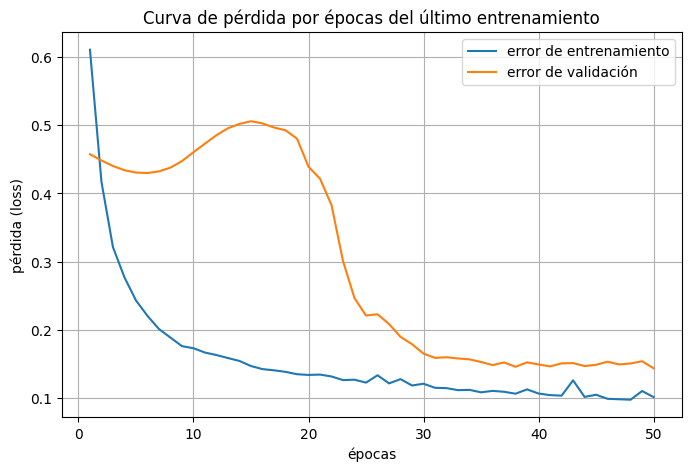

In [ ]:
# @title 1.2 Curva de pérdida por épocas

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

def obtener_ultimo_evento(ruta):
    archivos = glob.glob(os.path.join(ruta, "events.out.tfevents.*"))

    if len(archivos) == 0:
        raise FileNotFoundError(f"No se encontraron archivos de eventos en: {ruta}")

    ultimo_archivo = max(archivos, key=os.path.getmtime)
    print("Archivo usado:", ultimo_archivo)
    return ultimo_archivo

def obtener_loss_ultimo(ruta):
    archivo_evento = obtener_ultimo_evento(ruta)
    ea = event_accumulator.EventAccumulator(archivo_evento)
    ea.Reload()

    loss = ea.Scalars("loss")
    pasos = [x.step for x in loss]
    valores = [x.value for x in loss]

    return pasos, valores

# Leer pérdidas del experimento actual desde el Drive personal
RUTA_MODELO = os.path.join(OUTPUT_ROOT, Carpeta)

pasos_train, valores_train = obtener_loss_ultimo(
    os.path.join(RUTA_MODELO, "logs", "train")
)
pasos_val, valores_val = obtener_loss_ultimo(
    os.path.join(RUTA_MODELO, "logs", "val")
)

# La validación se guarda una vez por época
num_epocas = len(valores_val)

# El entrenamiento se guarda por iteración, entonces se agrupa por época
iters_por_epoca = len(valores_train) / num_epocas

loss_train_epoca = []

for e in range(num_epocas):
    inicio = int(round(e * iters_por_epoca))
    fin = int(round((e + 1) * iters_por_epoca))
    loss_train_epoca.append(np.mean(valores_train[inicio:fin]))

# Eje x en épocas
epocas = np.arange(1, num_epocas + 1)

# Graficar
plt.figure(figsize=(8,5))
plt.plot(epocas, loss_train_epoca, label="error de entrenamiento")
plt.plot(epocas, valores_val, label="error de validación")
plt.xlabel("épocas")
plt.ylabel("pérdida (loss)")
plt.title("Curva de pérdida por épocas del último entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

Carpeta actual:
/content/drive/.shortcut-targets-by-id/1hv288BzP1RHNX1IITagQzJTSBay_unfJ/OpenFWI
Namespace(device='cuda', dataset='flatvel-tutorial', file_size=None, anno_path='split_files', val_anno='split_files/Ejercicio_1_train.txt', output_path='/content/drive/MyDrive/OpenFWI_resultados/norma_L1/', save_name='norma_L1', suffix=None, model='InversionNet', norm='bn', up_mode=None, sample_spatial=1.0, sample_temporal=1, batch_size=50, workers=16, k=1, resume='/content/drive/MyDrive/OpenFWI_resultados/norma_L1/checkpoint.pth', vis=True, vis_suffix=None, vis_batch=2, vis_sample=3, missing=0, std=0)
torch version:  2.11.0+cu128
torchvision version:  0.26.0+cu128
Loading data
Loading validation data
Creating data loaders
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Ple

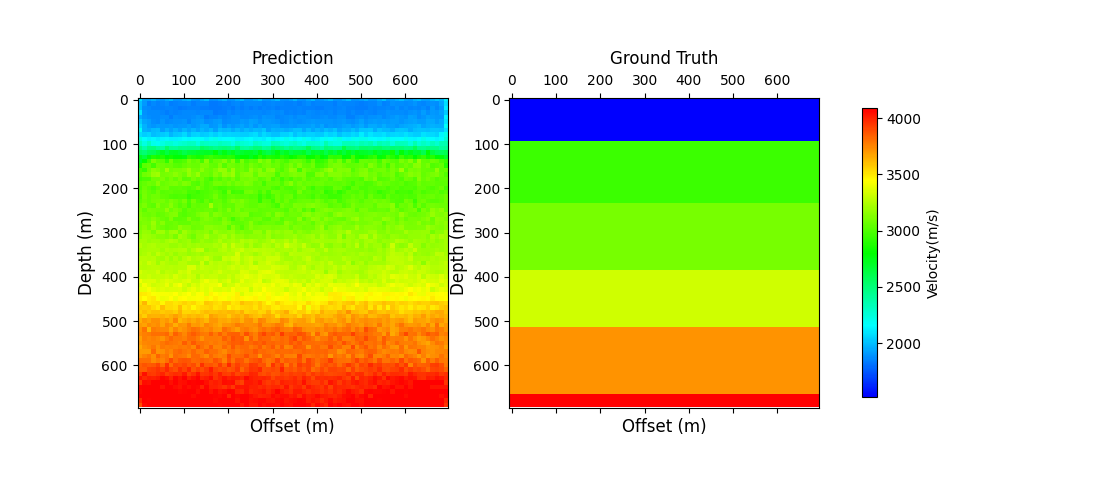

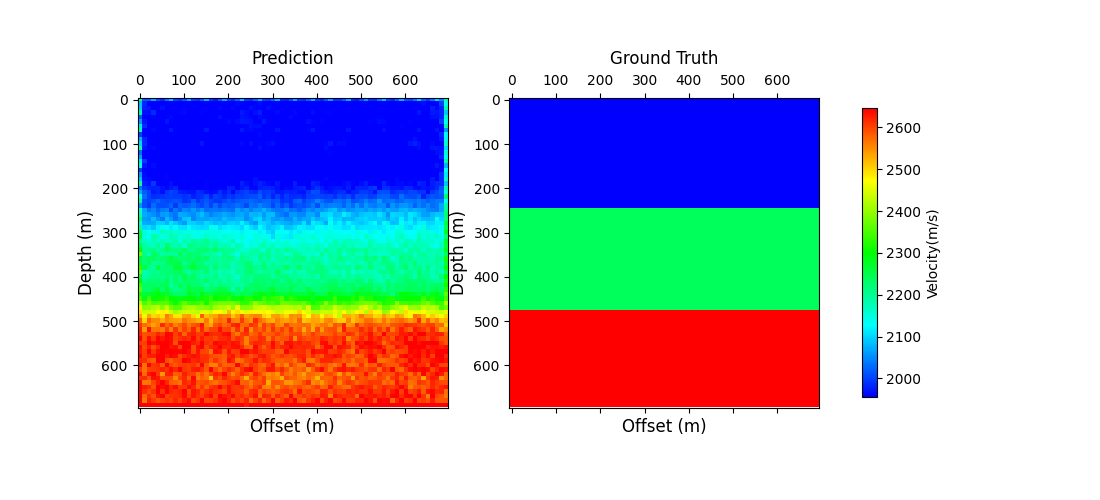

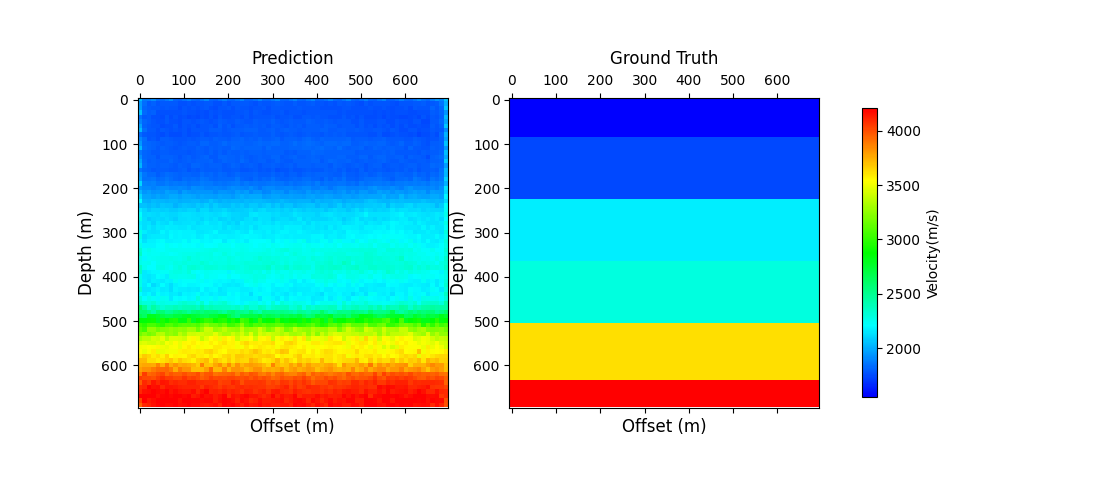

In [ ]:
#@title #1.3. Validación sobre el conjunto de entrenamiento
#@markdown Para verificar cómo se comporta la red entrenada en los datos de entrenamiento, establecemos "-v tutorial_train.txt"

#@markdown Para probar el rendimiento de la red en el conjunto de entrenamiento *fva_velocity1.npy*, *fva_data1.npy*, *fva_velocity2.npy* y *fva_data2.npy*

# Volver a la carpeta correcta de OpenFWI

import os

ruta_openfwi = "/content/drive/.shortcut-targets-by-id/1hv288BzP1RHNX1IITagQzJTSBay_unfJ/OpenFWI"

os.chdir(ruta_openfwi)

print("Carpeta actual:")
print(os.getcwd())

dataset = "flatvel-tutorial" #@param {type:"string"}
carpeta = "norma_L1" #@param {type:"string"}
nombre_red = "InversionNet" #@param {type:"string"}
archivo_test = "Ejercicio_1_train.txt" #@param {type:"string"}
checkpoint = "checkpoint.pth" #@param {type:"string"}

visualizar = True #@param {type:"boolean"}
batches_visualizar = 2 #@param {type:"integer"}
samples_por_batch = 3 #@param {type:"integer"}

flag_vis = "--vis" if visualizar else ""

!python test.py -ds {dataset} -n {carpeta} -m {nombre_red} -v {archivo_test} -r {checkpoint} {flag_vis} -vb {batches_visualizar} -vsa {samples_por_batch} --output-path {OUTPUT_ROOT}

from IPython.display import Image, display

base = os.path.join(OUTPUT_ROOT, carpeta, "visualization")

a = Image(f"{base}/V_0_0.png", width=600)
b = Image(f"{base}/V_0_1.png", width=600)
c = Image(f"{base}/V_0_2.png", width=600)

display(a, b, c)

In [ ]:
#@title 2.1 Entrenamiento con norma **L2**

Dataset = "flatvel-tutorial" #@param {type:"string"}
Carpeta = "norma_L2" #@param {type:"string"}
Nombre_de_la_red = "InversionNet" #@param {type:"string"}
Norma_L1 = 0.0 #@param {type:"number"}
Norma_L2 = 1.0 #@param {type:"number"}
Tensorboard = True #@param {type:"boolean"}
Conjunto_de_entrenamiento = "Ejercicio_1_train.txt" #@param {type:"string"}
Conjunto_de_validacion = "Ejercicio_1_val.txt" #@param {type:"string"}
Learning_rate = 0.0001 #@param {type:"number"}
Batch_size = 120 #@param {type:"integer"}
Epocas_por_bloque = 10 #@param {type:"integer"}
Bloques = 5 #@param {type:"integer"}
Workers = 2 #@param {type:"integer"}

flag_tensorboard = "--tensorboard" if Tensorboard else ""

!python train.py -ds {Dataset} -n {Carpeta} -m {Nombre_de_la_red} -g1v {Norma_L1} -g2v {Norma_L2} {flag_tensorboard} -t {Conjunto_de_entrenamiento} -v {Conjunto_de_validacion} --lr {Learning_rate} -b {Batch_size} -eb {Epocas_por_bloque} -nb {Bloques} -j {Workers} --output-path {OUTPUT_ROOT} --log-path {OUTPUT_ROOT}

Namespace(device='cuda', dataset='flatvel-tutorial', file_size=None, anno_path='split_files', train_anno='split_files/Ejercicio_1_train.txt', val_anno='split_files/Ejercicio_1_val.txt', output_path='/content/drive/MyDrive/OpenFWI_resultados/norma_L2/', log_path='/content/drive/MyDrive/OpenFWI_resultados/norma_L2/', save_name='norma_L2', suffix=None, model='InversionNet', up_mode=None, sample_spatial=1.0, sample_temporal=1, batch_size=120, lr=0.0001, lr_milestones=[], momentum=0.9, weight_decay=0.0001, lr_gamma=0.1, lr_warmup_epochs=0, epoch_block=10, num_block=5, workers=2, k=1, print_freq=50, resume=None, start_epoch=0, lambda_g1v=0.0, lambda_g2v=1.0, sync_bn=False, world_size=1, dist_url='env://', tensorboard=True, epochs=50)
torch version:  2.11.0+cu128
torchvision version:  0.26.0+cu128
Not using distributed mode
Loading data
Loading training data
Loading validation data
Creating data loaders
Creating model
Start training
Epoch: [0]  [0/2]  eta: 0:01:27  lr: 0.0001  samples/s: 2.81

Archivo usado: /content/drive/MyDrive/OpenFWI_resultados/norma_L2/logs/train/events.out.tfevents.1786091594.99d46dff3be5.15870.0
Archivo usado: /content/drive/MyDrive/OpenFWI_resultados/norma_L2/logs/val/events.out.tfevents.1786091594.99d46dff3be5.15870.1


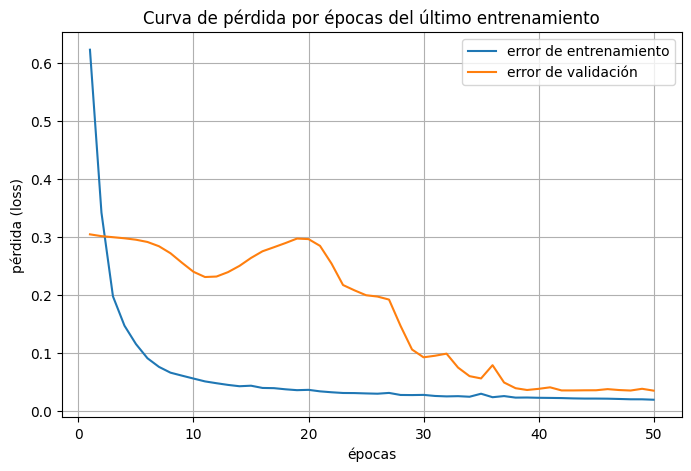

In [ ]:
# @title 2.2 Curva de pérdida por épocas

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

def obtener_ultimo_evento(ruta):
    archivos = glob.glob(os.path.join(ruta, "events.out.tfevents.*"))

    if len(archivos) == 0:
        raise FileNotFoundError(f"No se encontraron archivos de eventos en: {ruta}")

    ultimo_archivo = max(archivos, key=os.path.getmtime)
    print("Archivo usado:", ultimo_archivo)
    return ultimo_archivo

def obtener_loss_ultimo(ruta):
    archivo_evento = obtener_ultimo_evento(ruta)
    ea = event_accumulator.EventAccumulator(archivo_evento)
    ea.Reload()

    loss = ea.Scalars("loss")
    pasos = [x.step for x in loss]
    valores = [x.value for x in loss]

    return pasos, valores

# Leer pérdidas del experimento actual desde el Drive personal
RUTA_MODELO = os.path.join(OUTPUT_ROOT, Carpeta)

pasos_train, valores_train = obtener_loss_ultimo(
    os.path.join(RUTA_MODELO, "logs", "train")
)
pasos_val, valores_val = obtener_loss_ultimo(
    os.path.join(RUTA_MODELO, "logs", "val")
)

# La validación se guarda una vez por época
num_epocas = len(valores_val)

# El entrenamiento se guarda por iteración, entonces se agrupa por época
iters_por_epoca = len(valores_train) / num_epocas

loss_train_epoca = []

for e in range(num_epocas):
    inicio = int(round(e * iters_por_epoca))
    fin = int(round((e + 1) * iters_por_epoca))
    loss_train_epoca.append(np.mean(valores_train[inicio:fin]))

# Eje x en épocas
epocas = np.arange(1, num_epocas + 1)

# Graficar
plt.figure(figsize=(8,5))
plt.plot(epocas, loss_train_epoca, label="error de entrenamiento")
plt.plot(epocas, valores_val, label="error de validación")
plt.xlabel("épocas")
plt.ylabel("pérdida (loss)")
plt.title("Curva de pérdida por épocas del último entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

Carpeta actual:
/content/drive/.shortcut-targets-by-id/1hv288BzP1RHNX1IITagQzJTSBay_unfJ/OpenFWI
Namespace(device='cuda', dataset='flatvel-tutorial', file_size=None, anno_path='split_files', val_anno='split_files/Ejercicio_1_train.txt', output_path='/content/drive/MyDrive/OpenFWI_resultados/norma_L2/', save_name='norma_L2', suffix=None, model='InversionNet', norm='bn', up_mode=None, sample_spatial=1.0, sample_temporal=1, batch_size=50, workers=16, k=1, resume='/content/drive/MyDrive/OpenFWI_resultados/norma_L2/checkpoint.pth', vis=True, vis_suffix=None, vis_batch=2, vis_sample=3, missing=0, std=0)
torch version:  2.11.0+cu128
torchvision version:  0.26.0+cu128
Loading data
Loading validation data
Creating data loaders
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Ple

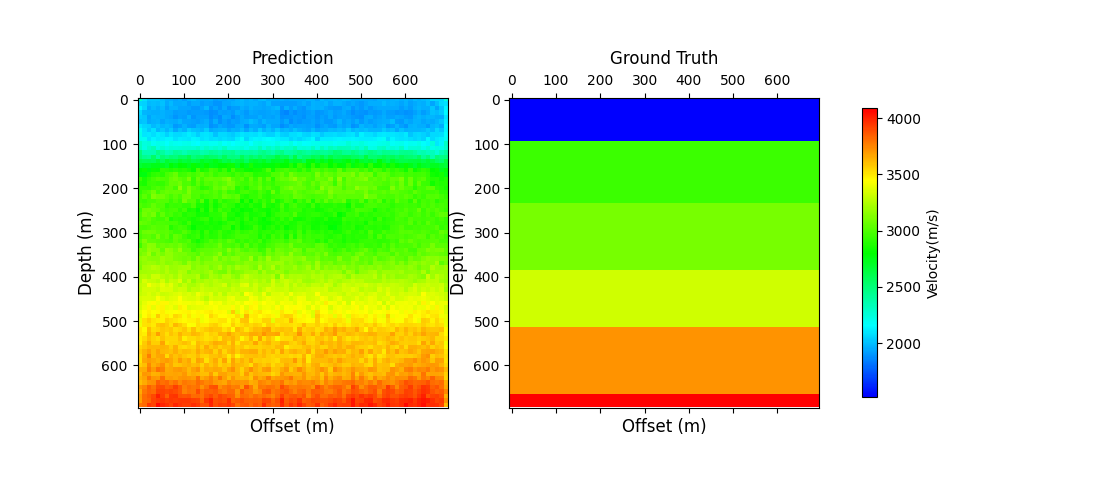

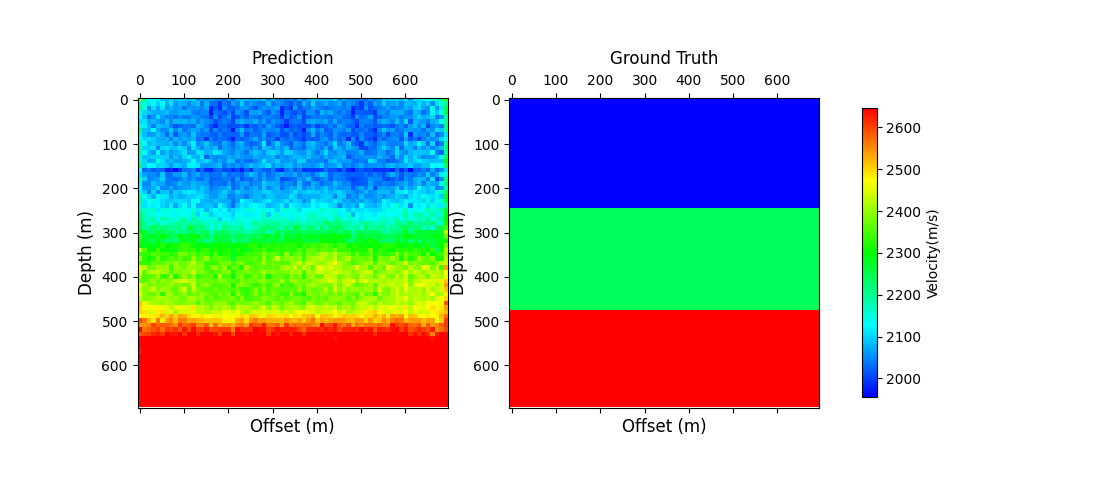

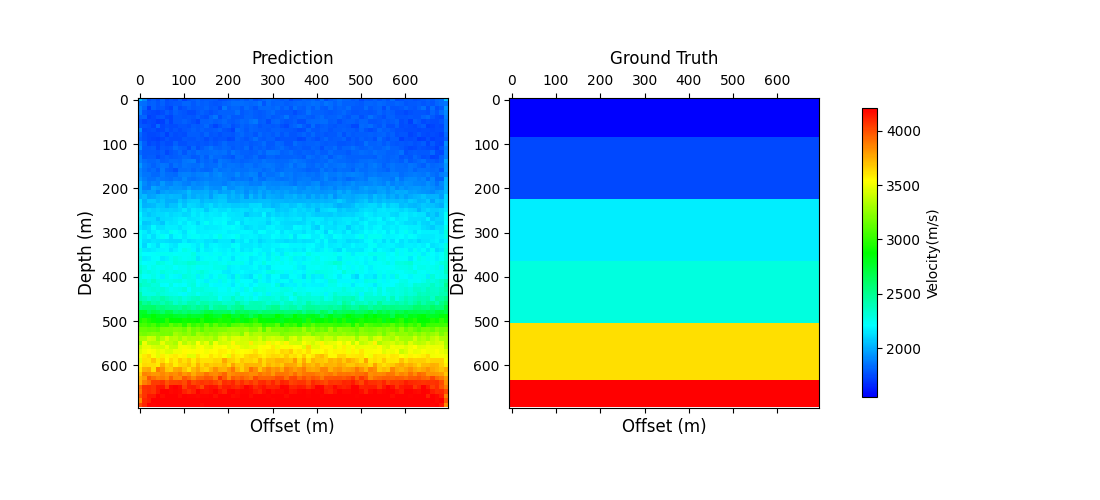

In [ ]:
#@title #2.3. Validación sobre el conjunto de entrenamiento
#@markdown Para verificar cómo se comporta la red entrenada en los datos de entrenamiento, establecemos "-v tutorial_train.txt"

#@markdown Para probar el rendimiento de la red en el conjunto de entrenamiento *fva_velocity1.npy*, *fva_data1.npy*, *fva_velocity2.npy* y *fva_data2.npy*

# Volver a la carpeta correcta de OpenFWI

import os

ruta_openfwi = "/content/drive/.shortcut-targets-by-id/1hv288BzP1RHNX1IITagQzJTSBay_unfJ/OpenFWI"

os.chdir(ruta_openfwi)

print("Carpeta actual:")
print(os.getcwd())

dataset = "flatvel-tutorial" #@param {type:"string"}
carpeta = "norma_L2" #@param {type:"string"}
nombre_red = "InversionNet" #@param {type:"string"}
archivo_test = "Ejercicio_1_train.txt" #@param {type:"string"}
checkpoint = "checkpoint.pth" #@param {type:"string"}

visualizar = True #@param {type:"boolean"}
batches_visualizar = 2 #@param {type:"integer"}
samples_por_batch = 3 #@param {type:"integer"}

flag_vis = "--vis" if visualizar else ""

!python test.py -ds {dataset} -n {carpeta} -m {nombre_red} -v {archivo_test} -r {checkpoint} {flag_vis} -vb {batches_visualizar} -vsa {samples_por_batch} --output-path {OUTPUT_ROOT}

from IPython.display import Image, display

base = os.path.join(OUTPUT_ROOT, carpeta, "visualization")

a = Image(f"{base}/V_0_0.png", width=600)
b = Image(f"{base}/V_0_1.png", width=600)
c = Image(f"{base}/V_0_2.png", width=600)

display(a, b, c)

In [ ]:
#@title 3.1 Entrenamiento con norma **L1+L2**

Dataset = "flatvel-tutorial" #@param {type:"string"}
Carpeta = "norma_L1_L2" #@param {type:"string"}
Nombre_de_la_red = "InversionNet" #@param {type:"string"}
Norma_L1 = 1.0 #@param {type:"number"}
Norma_L2 = 1.0 #@param {type:"number"}
Tensorboard = True #@param {type:"boolean"}
Conjunto_de_entrenamiento = "Ejercicio_1_train.txt" #@param {type:"string"}
Conjunto_de_validacion = "Ejercicio_1_val.txt" #@param {type:"string"}
Learning_rate = 0.0001 #@param {type:"number"}
Batch_size = 120 #@param {type:"integer"}
Epocas_por_bloque = 10 #@param {type:"integer"}
Bloques = 5 #@param {type:"integer"}
Workers = 2 #@param {type:"integer"}

flag_tensorboard = "--tensorboard" if Tensorboard else ""

!python train.py -ds {Dataset} -n {Carpeta} -m {Nombre_de_la_red} -g1v {Norma_L1} -g2v {Norma_L2} {flag_tensorboard} -t {Conjunto_de_entrenamiento} -v {Conjunto_de_validacion} --lr {Learning_rate} -b {Batch_size} -eb {Epocas_por_bloque} -nb {Bloques} -j {Workers} --output-path {OUTPUT_ROOT} --log-path {OUTPUT_ROOT}

Namespace(device='cuda', dataset='flatvel-tutorial', file_size=None, anno_path='split_files', train_anno='split_files/Ejercicio_1_train.txt', val_anno='split_files/Ejercicio_1_val.txt', output_path='/content/drive/MyDrive/OpenFWI_resultados/norma_L1_L2/', log_path='/content/drive/MyDrive/OpenFWI_resultados/norma_L1_L2/', save_name='norma_L1_L2', suffix=None, model='InversionNet', up_mode=None, sample_spatial=1.0, sample_temporal=1, batch_size=120, lr=0.0001, lr_milestones=[], momentum=0.9, weight_decay=0.0001, lr_gamma=0.1, lr_warmup_epochs=0, epoch_block=10, num_block=5, workers=2, k=1, print_freq=50, resume=None, start_epoch=0, lambda_g1v=1.0, lambda_g2v=1.0, sync_bn=False, world_size=1, dist_url='env://', tensorboard=True, epochs=50)
torch version:  2.11.0+cu128
torchvision version:  0.26.0+cu128
Not using distributed mode
Loading data
Loading training data
Loading validation data
Creating data loaders
Creating model
Start training
Epoch: [0]  [0/2]  eta: 0:01:10  lr: 0.0001  sample

Archivo usado: /content/drive/MyDrive/OpenFWI_resultados/norma_L1_L2/logs/train/events.out.tfevents.1786092087.99d46dff3be5.19011.0
Archivo usado: /content/drive/MyDrive/OpenFWI_resultados/norma_L1_L2/logs/val/events.out.tfevents.1786092087.99d46dff3be5.19011.1


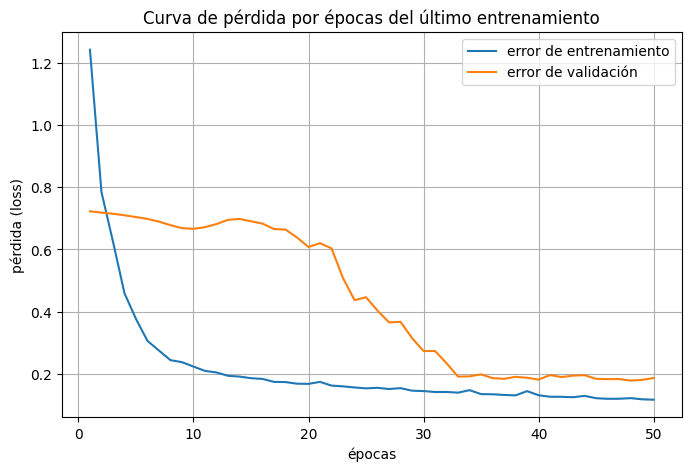

In [ ]:
# @title 3.2 Curva de pérdida por épocas

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

def obtener_ultimo_evento(ruta):
    archivos = glob.glob(os.path.join(ruta, "events.out.tfevents.*"))

    if len(archivos) == 0:
        raise FileNotFoundError(f"No se encontraron archivos de eventos en: {ruta}")

    ultimo_archivo = max(archivos, key=os.path.getmtime)
    print("Archivo usado:", ultimo_archivo)
    return ultimo_archivo

def obtener_loss_ultimo(ruta):
    archivo_evento = obtener_ultimo_evento(ruta)
    ea = event_accumulator.EventAccumulator(archivo_evento)
    ea.Reload()

    loss = ea.Scalars("loss")
    pasos = [x.step for x in loss]
    valores = [x.value for x in loss]

    return pasos, valores

# Leer pérdidas del experimento actual desde el Drive personal
RUTA_MODELO = os.path.join(OUTPUT_ROOT, Carpeta)

pasos_train, valores_train = obtener_loss_ultimo(
    os.path.join(RUTA_MODELO, "logs", "train")
)
pasos_val, valores_val = obtener_loss_ultimo(
    os.path.join(RUTA_MODELO, "logs", "val")
)

# La validación se guarda una vez por época
num_epocas = len(valores_val)

# El entrenamiento se guarda por iteración, entonces se agrupa por época
iters_por_epoca = len(valores_train) / num_epocas

loss_train_epoca = []

for e in range(num_epocas):
    inicio = int(round(e * iters_por_epoca))
    fin = int(round((e + 1) * iters_por_epoca))
    loss_train_epoca.append(np.mean(valores_train[inicio:fin]))

# Eje x en épocas
epocas = np.arange(1, num_epocas + 1)

# Graficar
plt.figure(figsize=(8,5))
plt.plot(epocas, loss_train_epoca, label="error de entrenamiento")
plt.plot(epocas, valores_val, label="error de validación")
plt.xlabel("épocas")
plt.ylabel("pérdida (loss)")
plt.title("Curva de pérdida por épocas del último entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

Carpeta actual:
/content/drive/.shortcut-targets-by-id/1hv288BzP1RHNX1IITagQzJTSBay_unfJ/OpenFWI
Namespace(device='cuda', dataset='flatvel-tutorial', file_size=None, anno_path='split_files', val_anno='split_files/Ejercicio_1_train.txt', output_path='/content/drive/MyDrive/OpenFWI_resultados/norma_L1_L2/', save_name='norma_L1_L2', suffix=None, model='InversionNet', norm='bn', up_mode=None, sample_spatial=1.0, sample_temporal=1, batch_size=50, workers=16, k=1, resume='/content/drive/MyDrive/OpenFWI_resultados/norma_L1_L2/checkpoint.pth', vis=True, vis_suffix=None, vis_batch=2, vis_sample=3, missing=0, std=0)
torch version:  2.11.0+cu128
torchvision version:  0.26.0+cu128
Loading data
Loading validation data
Creating data loaders
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to cr

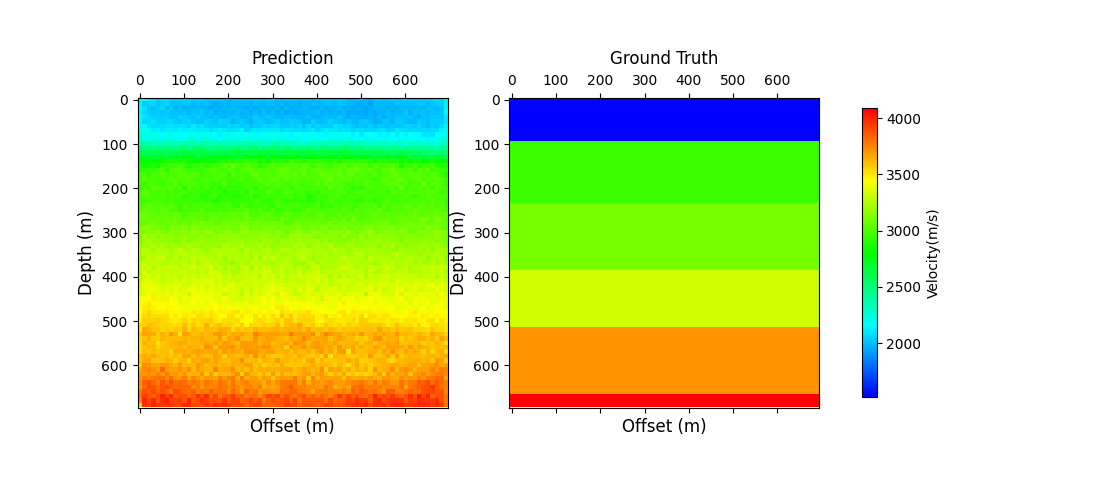

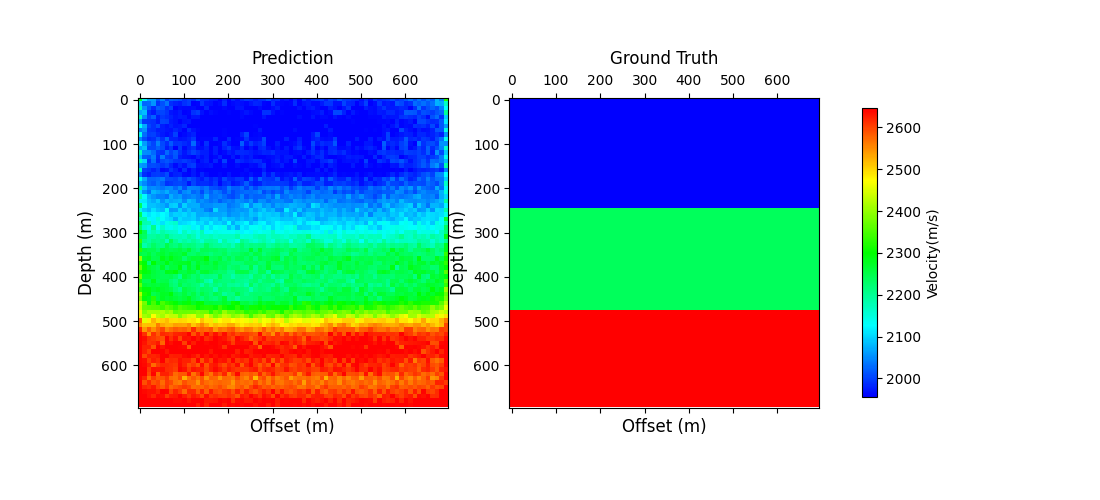

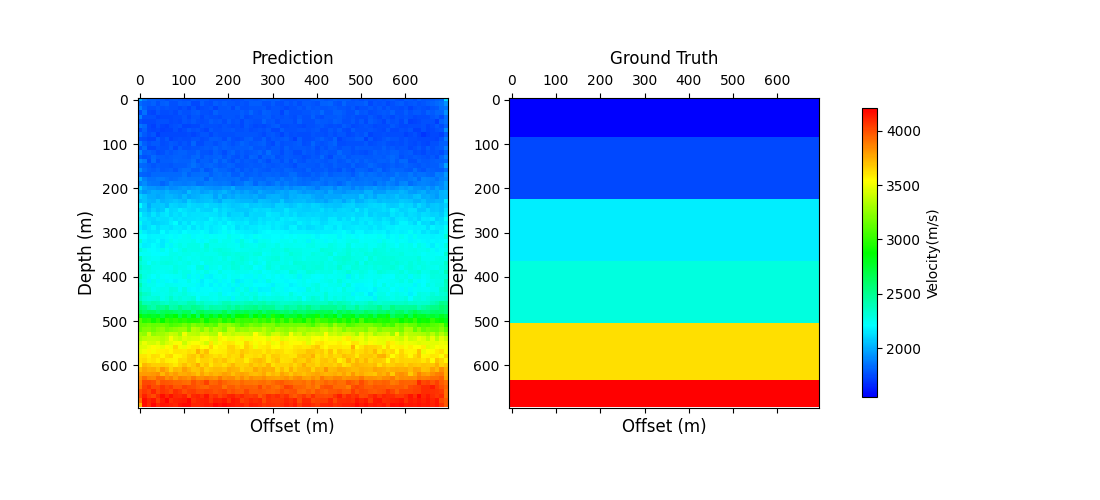

In [ ]:
#@title #3.3. Validación sobre el conjunto de entrenamiento
#@markdown Para verificar cómo se comporta la red entrenada en los datos de entrenamiento, establecemos "-v tutorial_train.txt"

#@markdown Para probar el rendimiento de la red en el conjunto de entrenamiento *fva_velocity1.npy*, *fva_data1.npy*, *fva_velocity2.npy* y *fva_data2.npy*

# Volver a la carpeta correcta de OpenFWI

import os

ruta_openfwi = "/content/drive/.shortcut-targets-by-id/1hv288BzP1RHNX1IITagQzJTSBay_unfJ/OpenFWI"

os.chdir(ruta_openfwi)

print("Carpeta actual:")
print(os.getcwd())

dataset = "flatvel-tutorial" #@param {type:"string"}
carpeta = "norma_L1_L2" #@param {type:"string"}
nombre_red = "InversionNet" #@param {type:"string"}
archivo_test = "Ejercicio_1_train.txt" #@param {type:"string"}
checkpoint = "checkpoint.pth" #@param {type:"string"}

visualizar = True #@param {type:"boolean"}
batches_visualizar = 2 #@param {type:"integer"}
samples_por_batch = 3 #@param {type:"integer"}

flag_vis = "--vis" if visualizar else ""

!python test.py -ds {dataset} -n {carpeta} -m {nombre_red} -v {archivo_test} -r {checkpoint} {flag_vis} -vb {batches_visualizar} -vsa {samples_por_batch} --output-path {OUTPUT_ROOT}

from IPython.display import Image, display

base = os.path.join(OUTPUT_ROOT, carpeta, "visualization")

a = Image(f"{base}/V_0_0.png", width=600)
b = Image(f"{base}/V_0_1.png", width=600)
c = Image(f"{base}/V_0_2.png", width=600)

display(a, b, c)